# Vanilla GCN: Full Local Project Pipeline

This notebook is the Jupyter equivalent of `scripts/train.py` and `scripts/evaluate.py`. It uses the project modules directly and runs locally on the Elliptic++ Transactions dataset.

Required files in `data/raw/`: `txs_features.csv`, `txs_classes.csv`, and `txs_edgelist.csv`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'default.yaml'
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
print('Project root:', PROJECT_ROOT)
print('Config:', CONFIG_PATH)
print('Data directory:', DATA_DIR)

Project root: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn
Config: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/configs/default.yaml
Data directory: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/data/raw


In [2]:
from vanilla_gcn.config import load_config
from vanilla_gcn.data.loader import load_elliptic_transactions
from vanilla_gcn.data.preprocessing import prepare_graph
from vanilla_gcn.models.vanilla_gcn import VanillaGCN
from vanilla_gcn.seed import set_seed
from vanilla_gcn.training.evaluation import evaluate_gcn
from vanilla_gcn.training.trainer import train_gcn
from vanilla_gcn.utils.checkpointing import save_checkpoint
from vanilla_gcn.utils.logging import setup_logging
from vanilla_gcn.visualization.embeddings import visualize_training_curves
import torch.optim as optim

cfg = load_config(CONFIG_PATH)
set_seed(cfg.seed)
setup_logging(level='INFO', log_file=PROJECT_ROOT / cfg.paths.logs / 'notebook_train.log', force=True)
print('Configuration loaded.')
print('Dataset:', cfg.data.dataset)
print('Seed:', cfg.seed)
print('Epochs:', cfg.training.epochs)

Configuration loaded.
Dataset: elliptic
Seed: 42
Epochs: 200


## 1. Load the Elliptic++ transaction graph

In [3]:
if cfg.data.dataset != 'elliptic':
    raise ValueError(f'This project pipeline expects dataset=elliptic, got {cfg.data.dataset!r}')

required_files = [
    DATA_DIR / 'txs_features.csv',
    DATA_DIR / 'txs_classes.csv',
    DATA_DIR / 'txs_edgelist.csv',
]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError('Missing dataset files:\n' + '\n'.join('  - ' + path for path in missing))

data = load_elliptic_transactions(
    raw_dir=DATA_DIR,
    train_ratio=cfg.data.train_ratio,
    val_ratio=cfg.data.validation_ratio,
    test_ratio=cfg.data.test_ratio,
    seed=cfg.seed,
)
print(data.summary())

2026-10-04 18:49:03 | INFO     | vanilla_gcn.data.loader | Reading features from /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/data/raw/txs_features.csv …
2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.loader | Reading classes from /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/data/raw/txs_classes.csv …
2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.loader | Reading edges from /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/data/raw/txs_edgelist.csv …
2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.loader | Loaded Elliptic++ Transactions: N=203769, F=183, labelled=46564 (illicit=4545, licit=42019), edges=234355
GraphData(name='elliptic_transactions')
  Nodes (N)        : 203769
  Features (F)     : 183
  Classes (C)      : 2
  Directed edges(E): 468710
  Train nodes      : 27938
  Val nodes        : 9312
  Test nodes       : 9314
  adjacency shape  : (203769, 203769)
  features shape   : (203769, 183)
  labels shape     : (203769,)


/Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/src/vanilla_gcn/data/loader.py:369: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:855.)
  adjacency = torch.sparse_coo_tensor(


## 2. Preprocess the graph

In [4]:
A_hat, A_tilde, X, y = prepare_graph(data.adjacency, data.features, data.labels)
print('Raw adjacency sparse:', data.adjacency.is_sparse)
print('Normalized adjacency sparse:', A_tilde.is_sparse)
print('Normalized adjacency entries:', A_tilde._nnz() if A_tilde.is_sparse else 'dense')
print('Feature shape:', tuple(X.shape))

2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.preprocessing | prepare_graph: starting GCN preprocessing pipeline
2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.preprocessing |   Input A shape : (203769, 203769)
2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.preprocessing |   Input X shape : (203769, 183)
2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.preprocessing |   Input y shape : (203769,)
2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.preprocessing |   Â (after self-loops) shape : (203769, 203769)
2026-10-04 18:49:06 | INFO     | vanilla_gcn.data.preprocessing |   Ã (normalized) shape : (203769, 203769)
Raw adjacency sparse: True
Normalized adjacency sparse: True
Normalized adjacency entries: 672479
Feature shape: (203769, 183)


## 3. Build and train the configured Vanilla GCN

In [5]:
model = VanillaGCN(
    input_dim=data.num_features,
    hidden_dim=cfg.model.hidden_dim,
    num_classes=data.num_classes,
    num_layers=cfg.model.num_layers,
    dropout=cfg.model.dropout,
    debug=cfg.debug.enabled,
)
model.print_summary()

history = train_gcn(
    model=model,
    A_tilde=A_tilde,
    X=X,
    y=y,
    train_mask=data.train_mask,
    val_mask=data.val_mask,
    epochs=cfg.training.epochs,
    lr=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
)

2026-10-04 18:49:06 | INFO     | vanilla_gcn.models.vanilla_gcn | VanillaGCN created: input_dim=183, hidden_dim=64, num_classes=2, num_layers=2, dropout=0.50
┌─────────────────────────────────────────┐
│              Vanilla GCN                │
├─────────────────────────────────────────┤
│  Input features     (N × 183)
│     ↓
│  GCN Layer 1             183 → 64  activation=relu
│     ↓
│  Output Layer (Logits)   64 → 2  activation=None
│     ↓
│  Logits             (N × 2)
├─────────────────────────────────────────┤
│  Total trainable parameters: 11840
└─────────────────────────────────────────┘
2026-10-04 18:49:07 | INFO     | vanilla_gcn.training.trainer | Starting GCN training: epochs=200, lr=0.0010, wd=0.000500
2026-10-04 18:49:07 | INFO     | vanilla_gcn.training.trainer | Epoch 001 | Train Loss: 8.0575 | Train Acc: 89.3% | Val Loss: 6.4036 | Val Acc: 89.5%
2026-10-04 18:49:09 | INFO     | vanilla_gcn.training.trainer | Epoch 010 | Train Loss: 1.5497 | Train Acc: 82.4% | Val Los

## 4. Evaluate the trained model

In [6]:
metrics = evaluate_gcn(
    model,
    A_tilde,
    X,
    y,
    data.train_mask,
    data.val_mask,
    data.test_mask,
)
print(metrics.summary())

2026-10-04 18:49:46 | INFO     | vanilla_gcn.training.evaluation | Evaluation Metrics
  Train loss : 0.1635  |  Train acc : 93.7%
  Val   loss : 0.1662  |  Val   acc : 93.8%
  Test  loss : 0.1654  |  Test  acc : 93.9%
Evaluation Metrics
  Train loss : 0.1635  |  Train acc : 93.7%
  Val   loss : 0.1662  |  Val   acc : 93.8%
  Test  loss : 0.1654  |  Test  acc : 93.9%


2026-10-04 18:49:46 | INFO     | vanilla_gcn.utils.checkpointing | Checkpoint saved: epoch=200, val_acc=93.8%, path=/Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/checkpoints/vanilla_gcn.pt
2026-10-04 18:49:46 | INFO     | vanilla_gcn.visualization.embeddings | Training curves saved to /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/figures/training_curves_notebook.png
Checkpoint: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/checkpoints/vanilla_gcn.pt
Training curves: /Users/s4n/Documents/clg/sem7/mlg/bitcoin-transaction-gcn/outputs/figures/training_curves_notebook.png


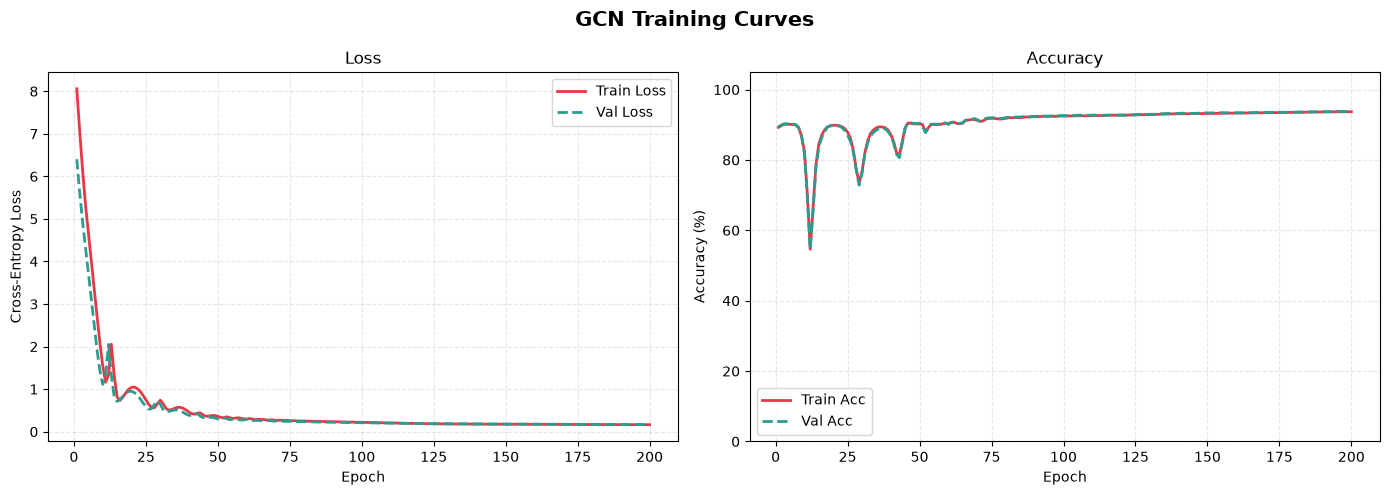

In [7]:
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
)
checkpoint_path = PROJECT_ROOT / cfg.paths.checkpoints / Path('vanilla_gcn.pt').name
save_checkpoint(model, optimizer, cfg, history, epoch=cfg.training.epochs, path=checkpoint_path)

figures_dir = PROJECT_ROOT / cfg.paths.figures
figures_dir.mkdir(parents=True, exist_ok=True)
curves_path = figures_dir / 'training_curves_notebook.png'
visualize_training_curves(
    history.train_loss,
    history.val_loss,
    history.train_acc,
    history.val_acc,
    history.epochs,
    save_path=curves_path,
)
print('Checkpoint:', checkpoint_path)
print('Training curves:', curves_path)